## 0. Imports and Definitions

In [1]:
import os
import copy
import torch
import numpy as np
import anndata as ad
import matplotlib.pyplot as plt

from sklearn.metrics import roc_curve, auc

import scgen
import scanpy as sc

# Also applies a compat patch for scgen's SCGENVAE.inference() vs scvi-tools>=1.1's
# MODULE_KEYS ("qz_m"/"qz_v" -> "qz")
from src.model.SCGEN.SCGEN_model import SCGENMixturePriorWrapper

from src.model.data_utils import (
    prepare_train_test_data,
    load_data,
    build_metacells,
    prepare_data,
)
from src.analysis.analysis_utils import Analyzer
from src.analysis.logistic_regression import (
    init_classifier,
    train_classifier,
    evaluate_training_error,
    evaluate_cfs_classification,
    generate_counterfactuals_scgen,
)
from src.analysis.mmd import ctrl_mmd_dists, mmd_dists, plot_mmd_dists
from src.analysis.cf_expressions import plot_mean_expression_comparison, plot_top_deg_violin

## 1. Load Data

In [2]:
dataset_args = {
    "dataset_name": "parse",
    "top_genes": 2000,
    "sigma_noise": 4,
    "batch_size": 512,
}

USE_METACELLS = False
DONOR = ["Donor1"]

if not USE_METACELLS:
    adata, labels_key, control_label = load_data(
        dataset_args["dataset_name"],
        dataset_args["top_genes"],
        log_transform=False,
        cell_types=["CD4 Memory"],
    )
else:
    adata, labels_key, control_label = load_data(
        dataset_args["dataset_name"],
        dataset_args["top_genes"],
        log_transform=False,
        cell_types=None,
        donors=DONOR,
    )
    print(adata.X.shape)
    adata = build_metacells(adata, group_keys=["cell_type", f"{labels_key}"])

dataset_args["top_genes"] = min(adata.shape[1], dataset_args["top_genes"])
adata.obs["cluster_idx"] = adata.obs[f"{labels_key}"].astype("category").cat.codes

## 2. Model

### 2.1 Training

In [3]:
scgen.SCGEN.setup_anndata(adata, batch_key=f"{labels_key}", labels_key="cell_type")
model = scgen.SCGEN(adata)
model.train(
    max_epochs=60,
    batch_size=128,
    early_stopping=True,
    early_stopping_patience=25
)

/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/jhoefer/sandbox/.venv/lib/python3.11/site-pack ...
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/jhoefer/sandbox/.venv/lib/python3.11/site-pack ...
You are using a CUDA device ('NVIDIA A100-PCIE-40GB') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [7]
/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/home/jhoefer/sandbox/.venv/lib/py

Training:   0%|          | 0/60 [00:00<?, ?it/s]


Detected KeyboardInterrupt, attempting graceful shutdown ...


SystemExit: 1

/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/IPython/core/interactiveshell.py:3709: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [ ]:
model_path = "/g/stegle/jhoefer/models/scgen"
model.save(os.path.join(model_path, "model.pt"), overwrite=True)

### 2.2 Loading

In [3]:
model_path = "/g/stegle/jhoefer/models/scgen"
model = scgen.SCGEN.load(os.path.join(model_path, "model.pt"), adata=adata)

INFO     File /g/stegle/jhoefer/models/scgen/model.pt/model.pt already downloaded                                  


/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/jhoefer/sandbox/.venv/lib/python3.11/site-pack ...


## 3. Evaluation

### 3.1 Paths

In [4]:
plot_dir = f"/home/jhoefer/sandbox/results/scgen/plots/"
csv_dir = f"/home/jhoefer/sandbox/results/scgen/csv/"
os.makedirs(plot_dir, exist_ok=True)
os.makedirs(csv_dir, exist_ok=True)

### 3.2 Clusters

In [ ]:
latent_X = model.get_latent_representation()
latent_adata = sc.AnnData(X=latent_X, obs=adata.obs.copy())

sc.pp.neighbors(latent_adata)
sc.tl.umap(latent_adata)
sc.pl.umap(latent_adata, color=[f'{labels_key}', 'cell_type'])

plt.tight_layout()
plt.savefig(f"{plot_dir}/scgen_umap.png", dpi=300)
plt.show()

/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/scanpy/neighbors/__init__.py:577: UserWarning: You’re trying to run this on 100 dimensions of `.X`, if you really want this, set `use_rep='X'`.
         Falling back to preprocessing with `sc.pp.pca` and default params.
  x = _choose_representation(self._adata, use_rep=use_rep, n_pcs=n_pcs)


KeyboardInterrupt: 

### 3.3 Counterfactuals

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dtype = torch.float32

kwargs_data = {
    "device": device,
    "dtype": dtype,
    "sigma_noise": 0.0,
}

wrapped_model = SCGENMixturePriorWrapper(model, adata, labels_key)

analyzer = Analyzer(
    adata,
    wrapped_model,
    kwargs_data,
    labels_key,
    control_label,
    plot_dir,
    csv_dir,
    checkpoint_path=None,
    conditions=[f"{labels_key}"],
    condition_type=None,
)

In [6]:
key = "IL-2"

In [7]:
x_cfs, z_cfs, all_source_labels, _ = generate_counterfactuals_scgen(analyzer, key=key)
# x_cfs stays in raw-count scale (see SCGENMixturePriorWrapper.predict), matching
# analyzer.adata, so adata_real.X needs no conversion here.

adata_real = analyzer.adata[analyzer.adata.obs[analyzer.labels_key] == key].copy()
adata_real.obs["origin"] = "original"

adata_cf = analyzer.adata[analyzer.adata.obs[analyzer.labels_key] != key].copy()
adata_cf.X = x_cfs.numpy()
adata_cf.obs["origin"] = "cfs"
adata_cf.obs["source"] = all_source_labels  # keep track of where each cf came from

adata_combined = ad.concat([adata_real, adata_cf])

analyzer_cfs = copy.deepcopy(analyzer)
analyzer_cfs.adata = adata_combined

num_original = adata_real.shape[0]
num_cfs = adata_cf.shape[0]

weights = torch.tensor(
    [1.0 / num_cfs, 1.0 / num_original],
    dtype=torch.float32,
    device=device,
)

weights = weights / weights.sum() * len(weights)

INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        


/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        


/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        


...

/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        


/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        


/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [8]:
cfs_classifier, cfs_train_dataloader, cfs_test_dataloader, cfs_train_dataset, cfs_adata_train, cfs_num_classes = init_classifier(analyzer_cfs, key=key, latent=False, hidden_dim=None, labels_key="origin")

cfs_accuracies, cfs_train_loss, cfs_val_loss, cfs_class_accuracies = train_classifier(
    cfs_classifier, cfs_train_dataloader, cfs_test_dataloader, weights, analyzer_cfs.device, num_epochs=10
)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:07<00:00,  1.25it/s]

Best Validation Accuracy: 0.9948


In [9]:
evaluate_training_error(analyzer, cfs_adata_train, "origin", cfs_num_classes, cfs_class_accuracies)
cats = cfs_train_dataset.cats[0].categories.tolist()
target_idx = cats.index("original")

,Class,Accuracy
0,cfs,1.000000
1,original,0.926716


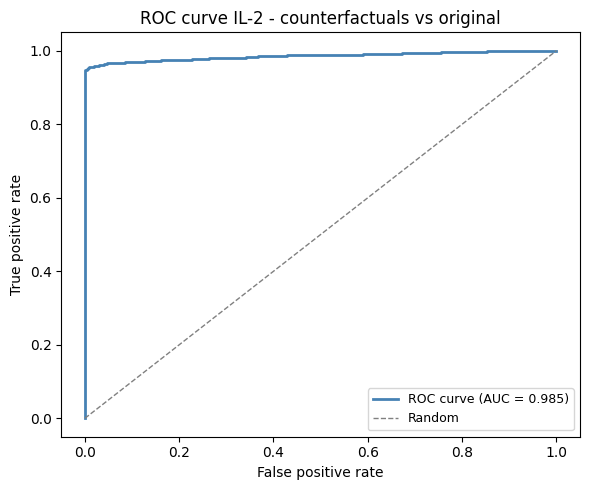

AUC: 0.985


In [10]:
cfs_classifier.eval()
all_probs = []
all_labels = []

with torch.no_grad():
    for x, y in cfs_test_dataloader:
        x = x.to(analyzer.device)
        logits = cfs_classifier(x)
        probs = torch.softmax(logits, dim=1)
        all_probs.append(probs.cpu().numpy())
        all_labels.append(y[0].argmax(dim=1).cpu().numpy())  # one-hot to int

all_probs = np.concatenate(all_probs, axis=0)
all_labels = np.concatenate(all_labels, axis=0)

# for binary classifier: use probability of positive class
fpr, tpr, _ = roc_curve(all_labels, all_probs[:, target_idx])
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, color="steelblue", lw=2, label=f"ROC curve (AUC = {roc_auc:.3f})")
ax.plot([0, 1], [0, 1], color="gray", lw=1, linestyle="--", label="Random")
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.set_title(f"ROC curve {key} - counterfactuals vs original")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(analyzer.plot_dir, f"roc_curve_{key}.png"), dpi=300)
plt.show()

print(f"AUC: {roc_auc:.3f}")

### 3.4 MMD

In [ ]:
ctrl_mmd = ctrl_mmd_dists(analyzer, key=key, log1p_transform=False)
print(f"Control MMD (random split): {ctrl_mmd:.4f}")
global_mmd, mmd_per_group = mmd_dists(
    analyzer, key=key, sigma=1.0, cf_fn=generate_counterfactuals_scgen, log1p_transform=False
)
print(f"Global MMD for {key}: {global_mmd}")

Control MMD (random split): 0.0004
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        


/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        


/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        


...

INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        


/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        


/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 11/11 [00:24<00:00,  2.25s/it]

Global MMD for IL-2: 0.0046797990798950195


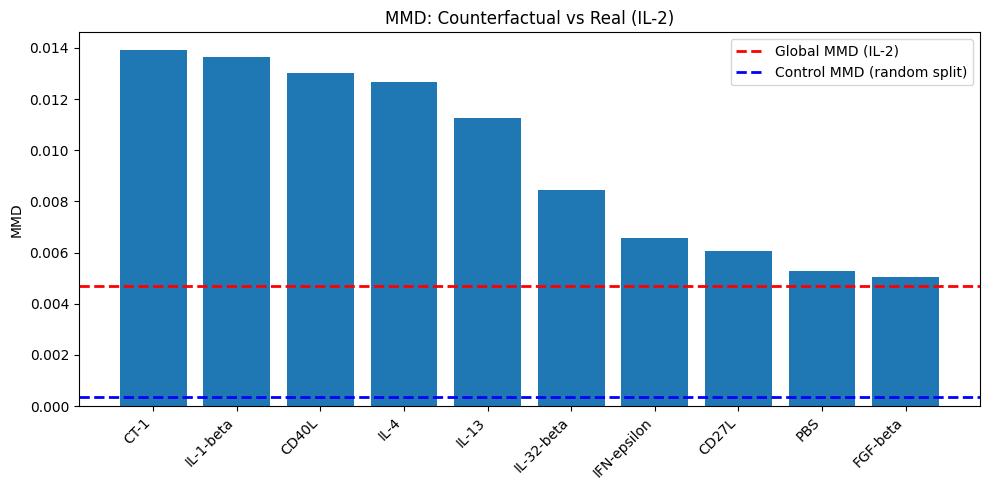

In [ ]:
plot_mmd_dists(analyzer, ctrl_mmd, global_mmd, mmd_per_group, key=key)

### 3.5 Mean Expressions

INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        


/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        


/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        


...

/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        


/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        


/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


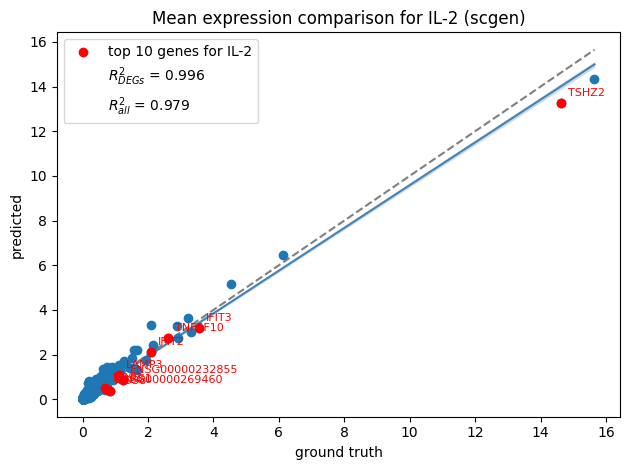

In [12]:
plot_mean_expression_comparison(analyzer, key=key, top_n=10, cfs_fn=generate_counterfactuals_scgen, log1p_transform=False, method="scgen")

### 3.6 Violin Plots

INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        


/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        


/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        


...

/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        


/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        


/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/jhoefer/sandbox/src/analysis/cf_expressions.py:281: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


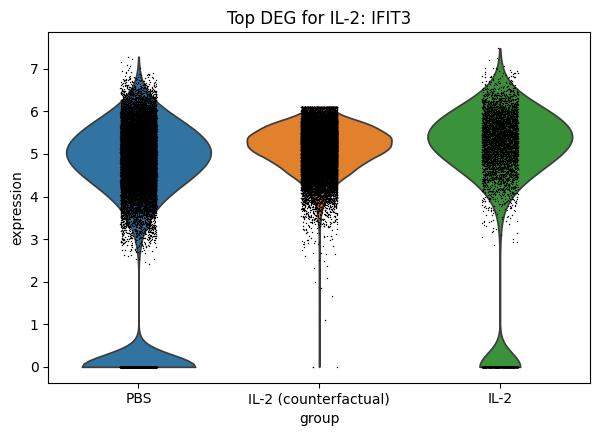

In [14]:
plot_top_deg_violin(analyzer, key=key, cfs_fn=generate_counterfactuals_scgen, log1p_transform=True)